# Medidas de Variabilidad

**Almacenes y Minería de Datos — Facultad de Ciencias, UNAM**

Se compara la dispersión de `edad_primer_union` y `num_hijos` entre el grupo
que reportó violencia de pareja y el que no, reutilizando
`calcular_medidas_variabilidad()` de `src/visualization/eda.py` y
`graficar_boxplot_variabilidad()` de `src/visualization/graficas.py`.


In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import polars as pl
from config.rutas import RUTA_DATA_PROCESSED, ARCHIVO_ENDIREH_LIMPIO, RUTA_REPORTS_FIGURES
from src.visualization.eda import calcular_medidas_variabilidad
from src.visualization.graficas import graficar_boxplot_variabilidad

df = pl.read_csv(RUTA_DATA_PROCESSED / ARCHIVO_ENDIREH_LIMPIO)
print("Filas:", df.shape[0])


Filas: 105753


In [2]:
filas = []
for columna in ["edad_primer_union", "num_hijos"]:
    for grupo_valor, etiqueta in [(True, "Sufrió violencia de pareja"), (False, "No sufrió")]:
        df_grupo = df.filter(pl.col("sufrio_violencia_pareja") == grupo_valor)
        m = calcular_medidas_variabilidad(df_grupo, columna, etiqueta)
        if m:
            filas.append(m)

tabla_variabilidad = pl.DataFrame(filas)
tabla_variabilidad


variable,grupo,n,rango,varianza,desv_std,CV_%,IQR
str,str,i64,f64,f64,f64,f64,f64
"""edad_primer_union""","""Sufrió violencia de pareja""",2824,60.0,80.570184,8.97609,40.150279,12.0
"""edad_primer_union""","""No sufrió""",4961,64.0,86.803636,9.316847,40.569184,14.0
"""num_hijos""","""Sufrió violencia de pareja""",17433,3.0,1.454333,1.205957,48.32089,2.0
"""num_hijos""","""No sufrió""",69089,3.0,1.403488,1.184689,46.946831,2.0


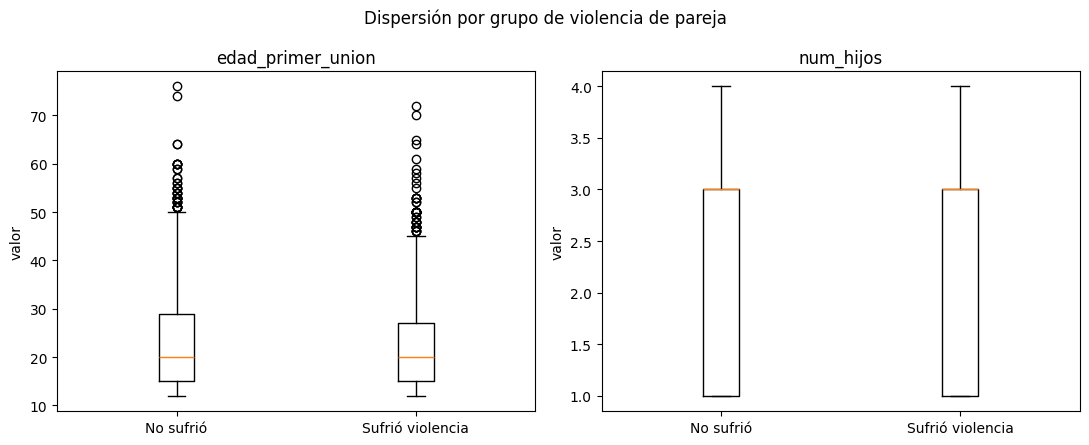

In [3]:
fig = graficar_boxplot_variabilidad(
    df,
    columnas=["edad_primer_union", "num_hijos"],
    ruta_salida=str(RUTA_REPORTS_FIGURES / "boxplot_variabilidad_p4.png"),
)

**Interpretación:** el coeficiente de variación (CV%) normaliza la dispersión
respecto a la media de cada grupo, lo que NOS permite comparar de forma justa
entre grupos con medias distintas.

En `edad_primer_union`, el CV es prácticamente igual entre ambos grupos
(40.15% en quien sufrió violencia de pareja vs. 40.57% en quien no) una
diferencia de apenas 0.4 puntos porcentuales. Esto **no** confirma la hipótesis
de que la violencia de pareja se asocie con mayor heterogeneidad en la edad de
primera unión: ambos grupos presentan un nivel de dispersión relativa casi
idéntico, visible también en el boxplot.

En `num_hijos` ocurre algo similar el CV es ligeramente más alto en el grupo
que sufrió violencia (48.32% vs. 46.95%), pero la diferencia es pequeña y los
boxplots son visualmente casi idénticos.
Por lo que no hay evidencia fuerte de que la violencia de pareja se relacione con una
mayor dispersión en el número de hijos reportados.

En ambas variables, la similitud en el CV entre grupos sugiere que, vistas de
forma aislada, no explican diferencias relevantes asociadas a la violencia de
pareja por lo que habría que cruzarlas con otras variables (como `nivel_escolaridad` o
`estrato_socioeconomico`) para buscar patrones que no se ven al comparar solo
estos dos grupos en bloque.